In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras

In [2]:
time_steps = np.linspace(0,50,500)
series = np.sin(time_steps)

In [3]:
window_size=10

x = []
y = []

for i in range(len(series) - window_size):
    x.append(series[i: i + window_size])
    y.append(series[i + window_size])

x = np.array(x)
y = np.array(y)

In [4]:
print("Shape of X: ",x.shape)
print("Shape of Y: ",y.shape)

Shape of X:  (490, 10)
Shape of Y:  (490,)


In [5]:
x = x.reshape(490, 10, 1)
# x = np.expand_dims(x, axis=-1)

In [6]:
print("Shape of X: ",x.shape)

Shape of X:  (490, 10, 1)


In [7]:
print(x[:3].flatten())

[0.         0.10003281 0.19906213 0.2960945  0.39015654 0.48030464
 0.56563445 0.64528998 0.71847213 0.78444678 0.10003281 0.19906213
 0.2960945  0.39015654 0.48030464 0.56563445 0.64528998 0.71847213
 0.78444678 0.84255206 0.19906213 0.2960945  0.39015654 0.48030464
 0.56563445 0.64528998 0.71847213 0.78444678 0.84255206 0.89220511]


In [8]:
print(y[:3].flatten())

[0.84255206 0.89220511 0.93290779]


In [9]:
model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(units=16, input_shape=(window_size,1)),

    tf.keras.layers.Dense(units=1)
])

C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 16)                  │             288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 305 (1.19 KB)

 Trainable params: 305 (1.19 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [12]:
history = model.fit(
    x,
    y,
    epochs=30,
    verbose=1
)

Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4548 - mae: 0.6163
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1563 - mae: 0.3622 
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0569 - mae: 0.2190 
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0162 - mae: 0.1105
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0065 - mae: 0.0672
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0046 - mae: 0.0592
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0035 - mae: 0.0508
Epoch 8/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0029 - mae: 0.0463
Epoch 9/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0025 - mae: 0.0435
Epoch 10/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0022 - mae: 0.0415
Epoch 11/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0020 - mae: 0.0397
Epoch 12/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0018 - mae: 0.0379
Epoch 13/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/s

In [13]:
simple_pred = model.predict(x[0:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step


In [14]:
print(f"Prediction: {simple_pred[0][0]:.5f}")
print(f"Actual: {y[0]:.5f}")

Prediction: 0.87088
Actual: 0.84255


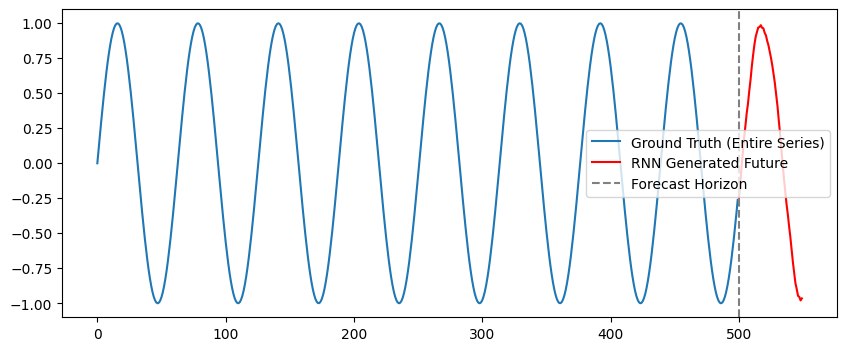

In [15]:
import matplotlib.pyplot as plt

# 1. Start with the very last window from your dataset
# Shape must remain 3D: (1, window_size, 1)
current_window = x[-1:].copy()

future_predictions = []

for _ in range(50):
    # Predict the single next value
    pred = model.predict(current_window, verbose=0)  # Shape: (1, 1)
    
    # Store the scalar prediction
    future_predictions.append(pred[0, 0])
    
    # Reshape prediction to match a single timestep: shape (1, 1, 1)
    pred_reshaped = pred.reshape(1, 1, 1)
    
    # Slide the window: drop the oldest step (index 0) and append the new prediction
    # Concatenate along axis=1 (the timesteps axis)
    current_window = np.concatenate([current_window[:, 1:, :], pred_reshaped], axis=1)

# 2. Plot past vs. predicted future
plt.figure(figsize=(10, 4))
plt.plot(range(len(series)), series, label="Ground Truth (Entire Series)")
plt.plot(range(len(series), len(series) + 50), future_predictions, label="RNN Generated Future", color="red")
plt.axvline(x=len(series), color="gray", linestyle="--", label="Forecast Horizon")
plt.legend()
plt.show()